In [1]:
from langchain_core.tools import tool
import httpx
from geopy.geocoders import Nominatim
import json

def get_coordinates(city_name: str) -> tuple[float, float]:
    """도시 이름을 받아 위도와 경도를 반환합니다."""
    geolocator = Nominatim(user_agent="weather_app_langgraph")
    location = geolocator.geocode(city_name)
    if location:
        return location.latitude, location.longitude
    raise ValueError(f"좌표를 찾을 수 없습니다: {city_name}")

@tool
def get_weather(city_name: str) -> str:
    """도시 이름을 받아 해당 도시의 현재 날씨 정보를 반환합니다."""
    print(f"날씨 조회: {city_name}")
    latitude, longitude = get_coordinates(city_name)
    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true"
    response = httpx.get(url)
    response.raise_for_status()
    return json.dumps(response.json())

tools = [get_weather]

In [2]:
get_coordinates("부산")

(35.1799528, 129.0752365)

In [3]:
tools[0].invoke({"city_name": "부산"})

날씨 조회: 부산


'{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.050067901611328125, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 26.0, "current_weather_units": {"time": "iso8601", "interval": "seconds", "temperature": "\\u00b0C", "windspeed": "km/h", "winddirection": "\\u00b0", "is_day": "", "weathercode": "wmo code"}, "current_weather": {"time": "2025-09-23T07:00", "interval": 900, "temperature": 23.6, "windspeed": 13.0, "winddirection": 51, "is_day": 1, "weathercode": 1}}'

In [ ]:
from langgraph.prebuilt import ToolNode # 에이전트와 도구 간의 인터페이스 역할을 하며, 언어 모델의 지시에 따라 실제 도구 실행을 담당하는 핵심적인 중간 다리
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash").bind_tools(tools)
tool_node = ToolNode([get_weather])

def call_model(state: MessagesState):
    return {"messages": [model.invoke(state["messages"])]}

graph_builder = StateGraph(MessagesState)
graph_builder.add_node("call_model", call_model)
graph_builder.add_node("tool_node", tool_node)

graph_builder.add_edge(START, "call_model")
graph_builder.add_conditional_edges(
    "call_model",
    lambda s: "tool_node" if s["messages"][-1].tool_calls else END,
    {"tool_node": "tool_node", END: END},
)
graph_builder.add_edge("tool_node", "call_model")

graph = graph_builder.compile()

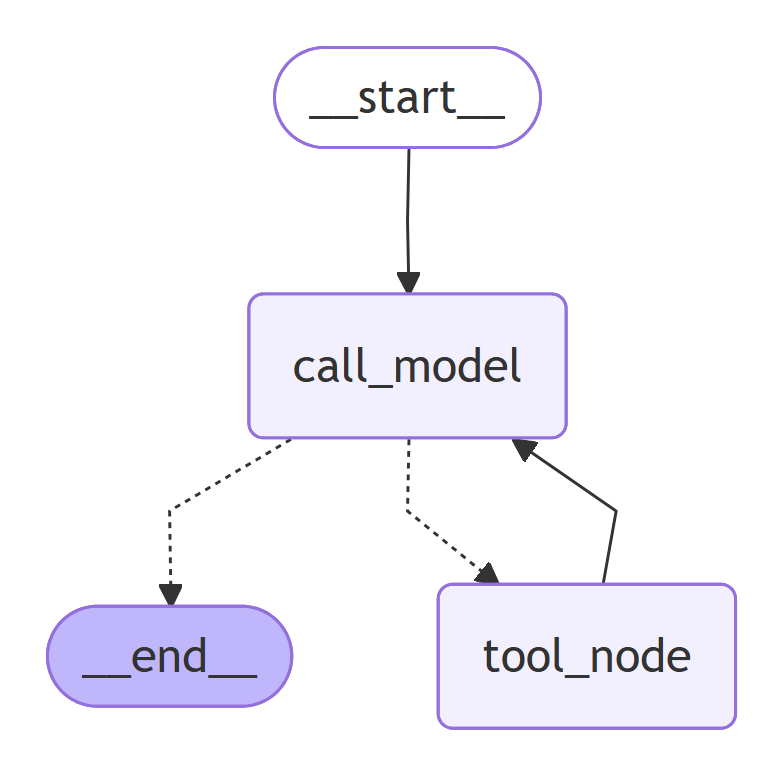

In [ ]:
# [venv 경로]\Lib\site-packages\langchain_core\runnables\graph_mermaid.py
# 파일을 열고 `_render_mermaid_using_pyppeteer` 함수 내부에 있는 `pyppeteer.launch()` 호출 부분을 찾아 `executablePath` 인자를 추가한다.
# browser = await launch(executablePath=r'C:\Program Files\Google\Chrome\Application\chrome.exe')
import nest_asyncio
from IPython.display import display, Image
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod

# nest_asyncio를 적용하여 이벤트 루프 중첩 오류를 해결한다.
nest_asyncio.apply()

# (옵션) 그래프를 시각화
# 이 코드는 이미 langchain_core 라이브러리의 pyppeteer.launch()에 
# executablePath가 하드코딩된 상태를 전제로 한다.
display(Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

In [7]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
from langchain_core.messages import HumanMessage

query = "부산 날씨 어때?"
result = graph.invoke({"messages": [HumanMessage(content=query)]})

result

날씨 조회: 부산


{'messages': [HumanMessage(content='부산 날씨 어때?', additional_kwargs={}, response_metadata={}, id='1364e988-89d9-4e83-bddb-91672415dd2f'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city_name": "\\ubd80\\uc0b0"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--d86e00d4-4840-40fe-aeaa-20105d5833b5-0', tool_calls=[{'name': 'get_weather', 'args': {'city_name': '부산'}, 'id': '84df8a76-3c36-411c-aedc-b7cd93f3a08e', 'type': 'tool_call'}], usage_metadata={'input_tokens': 37, 'output_tokens': 8, 'total_tokens': 45, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.05626678466796875, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 26.0, "current_weather_units": {"time": "iso8601", "interval": "sec

In [9]:
result['messages'][-1].content

'부산의 현재 날씨는 23.6°C이고, 바람은 13km/h로 불고 있습니다.'

In [10]:
from langchain_core.messages import HumanMessage

query = "랭그래프에 대해 핵심만 간단히 설명해줘."
result = graph.invoke({"messages": [HumanMessage(content=query)]})

result

{'messages': [HumanMessage(content='랭그래프에 대해 핵심만 간단히 설명해줘.', additional_kwargs={}, response_metadata={}, id='c302c839-9467-4320-b1c7-738a34422a55'),
  AIMessage(content='죄송합니다. 제가 랭그래프에 대해 답변을 드릴 수 없습니다.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--31c0689e-4259-4a18-9f87-ad06691dff59-0', usage_metadata={'input_tokens': 47, 'output_tokens': 22, 'total_tokens': 69, 'input_token_details': {'cache_read': 0}})]}

In [11]:
print(result['messages'][-1].content)

죄송합니다. 제가 랭그래프에 대해 답변을 드릴 수 없습니다.
